In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import sys
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
import numpy as onp
# import jax.numpy as np
# from jax import random, vmap, jit
# from jax.experimental.ode import odeint
# from jax import config
#from torch.utils import data
from functools import partial

import tensorflow as tf
import time


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras import layers, activations

#from tqdm import trange
import matplotlib.pyplot as plt

DTYPE='float32'
tf.keras.backend.set_floatx(DTYPE)
SEED=42
os.environ['PYTHONHASHSEED']=str(SEED)
onp.random.seed(SEED)
tf.random.set_seed(SEED)

ModuleNotFoundError: No module named 'tqdm'

In [2]:
class Deeponet(tf.keras.Model):
    def __init__(self, branch_layers, trunk_layers, activation=tf.nn.tanh, **kwargs):
        super(Deeponet, self).__init__(**kwargs)
        self.trunk_layers = trunk_layers
        self.branch_layers = branch_layers
        self.B = [layers.Dense(width, activation=activation,kernel_initializer="glorot_normal") for width in branch_layers[1:-1]]
        self.T = [layers.Dense(width, activation=activation,kernel_initializer="glorot_normal") for width in trunk_layers[1:-1]]
        self.B_out = layers.Dense(branch_layers[-1], activation=None,kernel_initializer="glorot_normal")
        self.T_out = layers.Dense(trunk_layers[-1], activation=None,kernel_initializer="glorot_normal")
        self.bias = tf.Variable([0.0,0.0,0.0],trainable=True, dtype=DTYPE)
        self.nn_half = branch_layers[1]//3
        
    def call(self,input):
        output1 = input[0]
        output2 = input[1]
        for layer in self.B:
            output1 = layer(output1)
        output1 = self.B_out(output1)
        
        for layer in self.T:
            output2 = layer(output2)
        output2 = self.T_out(output2)
        
        output = layers.Multiply()([output1, output2])
        o1 = tf.reduce_sum(output[:,:self.nn_half],axis=1)[:,None] + self.bias[0]
        o2 = tf.reduce_sum(output[:,self.nn_half:2*self.nn_half],axis=1)[:,None] + self.bias[1]
        o3 = tf.reduce_sum(output[:,2*self.nn_half:],axis=1)[:,None] + self.bias[2]
        return o1, o2, o3

In [3]:
class Modified_deeponet(tf.keras.Model):
    def __init__(self, branch_layers, trunk_layers, activation=tf.nn.tanh, **kwargs):
        super(Modified_deeponet, self).__init__(**kwargs)
        self.trunk_layers = trunk_layers
        self.branch_layers = branch_layers
        self.U = layers.Dense(branch_layers[1], activation=activation,kernel_initializer="glorot_normal")
        self.V = layers.Dense(trunk_layers[1], activation=activation,kernel_initializer="glorot_normal")
        self.B = [layers.Dense(width, activation=activation,kernel_initializer="glorot_normal") for width in branch_layers[1:-1]]
        self.T = [layers.Dense(width, activation=activation,kernel_initializer="glorot_normal") for width in trunk_layers[1:-1]]
        self.B_out = layers.Dense(branch_layers[-1], activation=None,kernel_initializer="glorot_normal")
        self.T_out = layers.Dense(trunk_layers[-1], activation=None,kernel_initializer="glorot_normal")
        self.bias = tf.Variable([0.0,0.0,0.0],trainable=True, dtype=DTYPE)
        self.nn_half = branch_layers[1]//3
        
    def call(self,input):
        output1 = input[0]
        output2 = input[1]
        U = self.U(output1)
        V = self.V(output2)
        for layer in self.B:
            output1 = layer(output1)
            output1 = layers.Add()([layers.Multiply()([output1, U]),layers.Multiply()([1 - output1, V])])
        output1 = self.B_out(output1)
        
        for layer in self.T:
            output2 = layer(output2)
            output2 = layers.Add()([layers.Multiply()([output2, U]),layers.Multiply()([1 - output2, V])])
        output2 = self.T_out(output2)
        
        output = layers.Multiply()([output1, output2])
        o1 = tf.reduce_sum(output[:,:self.nn_half],axis=1)[:,None] + self.bias[0]
        o2 = tf.reduce_sum(output[:,self.nn_half:2*self.nn_half],axis=1)[:,None] + self.bias[1]
        o3 = tf.reduce_sum(output[:,2*self.nn_half:],axis=1)[:,None] + self.bias[2]
        return o1, o2, o3

In [4]:
class PI_DeepONet:
    def __init__(self,branch_layers,trunk_layers,activation=tf.nn.tanh):
        #lr = tf.keras.optimizers.schedules.ExponentialDecay(0.001,1000,0.9)
        self.tf_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.001,beta_1=.99,beta_2=0.999)
        self.weight_optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=0.005)
        self.weight = tf.Variable([1.0,1.0,1.0],trainable=True,dtype=DTYPE)
        self.model = Modified_deeponet(branch_layers,trunk_layers,activation)
        self.model.build([(None,4*m),(None,1)])
        self.loss_log = []


    @tf.function
    def loss(self,batch):
        inputs, outputs = batch
        u, X = inputs
        t   = X[:,0:1]
        v11 = X[:,1:2]
        v22 = X[:,2:3]
        v12 = X[:,3:4]
        v21 = X[:,4:5]
        with tf.GradientTape(persistent=True) as tape:
            tape.watch([u,t])
            σ11, σ22, σ12 = self.model([u,t])
            σ11 = σ11 * t
            σ22 = σ22 * t
            σ12 = σ12 * t
        σ11_t = tape.gradient(σ11, t)
        σ22_t = tape.gradient(σ22, t)
        σ12_t = tape.gradient(σ12, t)
        del tape
        γd11 = 2*v11
        γd22 = 2*v22
        γd12 = (v12 + v21)
        ω12  = (v12 - v21)
        F11 = -τ*(σ11*γd11 + σ12*γd12) + (α*τ/η0)*(σ11**2 + σ12**2)
        F22 = -τ*(σ12*γd12 + σ22*γd22) + (α*τ/η0)*(σ12**2 + σ22**2)
        F12 = -τ*(σ11*γd12 + σ12*γd22 + γd11*σ12 + γd12*σ22)/2 + (α*τ/η0)*(σ11*σ12 + σ12*σ22)
        # The model differential equations
        du1 = σ11_t - (η0*γd11/τ - σ11/τ - ω12*σ12 - F11/τ)
        du2 = σ22_t - (η0*γd22/τ - σ22/τ + ω12*σ12 - F22/τ)
        du3 = σ12_t - (η0*γd12/τ - σ12/τ - (ω12*σ22 - σ11*ω12)/2 - F12/τ)
        #loss_value = tf.reduce_mean(tf.square(du1)) + tf.reduce_mean(tf.square(du2)) + tf.reduce_mean(tf.square(du3))
        loss_value = self.weight[0]**2 * tf.reduce_mean(tf.square(du1)) + self.weight[1]**2 * tf.reduce_mean(tf.square(du2)) + self.weight[2]**2 * tf.reduce_mean(tf.square(du3))
        return loss_value

    @tf.function
    def grad(self,batch):
        with tf.GradientTape() as tape:
           loss_value = self.loss(batch)
        grads = tape.gradient(loss_value, self.variables)
        del tape
        return loss_value, grads

    @tf.function
    def train_op(self,batch):
        self.variables = self.model.trainable_variables
        self.variables.extend([self.weight])
        loss_value, grads = self.grad(batch)
        self.tf_optimizer.apply_gradients(zip(grads[:-1],self.variables[:-1]))
        self.weight_optimizer.apply_gradients(zip([-grads[-1]],[self.variables[-1]]))
        return loss_value

    def train(self,physics_dataset,nIter=1000):
        pbar = trange(nIter)
        physics_data = iter(physics_dataset)
        for i in pbar:
            # shuffled_indices = tf.random.shuffle(indices)
            # u_train = tf.gather(u,shuffled_indices[:batch_size])
            # X_train = tf.gather(X,shuffled_indices[:batch_size])
            # loss_value = self.train_op(u_train,X_train)
            physics_batch = next(physics_data)
            loss_value = self.train_op(physics_batch)
            if i % 100 == 0:
                pbar.set_postfix({'Loss':loss_value.numpy(),'weight':self.weight.numpy()})
                self.loss_log.append(loss_value)

    def predict(self, u_star, x_star):
        σ11, σ22, σ12 = self.model([u_star,x_star])
        σ11 = (σ11 * x_star).numpy()
        σ22 = (σ22 * x_star).numpy()
        σ12 = (σ12 * x_star).numpy()
        s_pred = onp.stack([σ11,σ22,σ12],axis=1)
        return s_pred

    def save(self, path):
        self.model.save(path)

    def load_model(self, path, compile_model=False):
        self.model = tf.keras.models.load_model(path, compile=compile_model)

In [5]:
# Define RBF kernel
def RBF(x1, x2, params):
    outputscale, lengthscales = params
    diffs = np.expand_dims(x1 / lengthscales, 1) - \
            np.expand_dims(x2 / lengthscales, 0)
    r2 = np.sum(diffs**2, axis=2)
    return outputscale * np.exp(-0.5 * r2)

def GP_sample(key):
    N = 2048
    gp_params = (output_scale, length_scale)
    jitter = 1e-10
    X = np.linspace(0, tmax1, N)[:,None]
    K = RBF(X, X, gp_params)
    L = np.linalg.cholesky(K + jitter*np.eye(N))
    gp_sample = np.dot(L, random.normal(key, (N,)))
    u_fn = lambda x : np.interp(x, X.flatten(), gp_sample)
    return u_fn

In [6]:
# Geneate test data corresponding to N input sample
def generate_simpleshear_data(key, N, m, P):
    def generate_one_test_data(key, m=100, P=100):
        def odes(sigma_0,t,gradv):
            σ11,σ22,σ12 = sigma_0
            v11,v22,v12,v21 = gradv
            γd11 = 2*v11
            γd22 = 2*v22
            γd12 = (v12 + v21 ) * np.cos(omega * t)
            ω12  = (v12 - v21 ) * np.cos(omega * t)
            F11 = -τ*(σ11*γd11 + σ12*γd12) + (α*τ/η0)*(σ11**2 + σ12**2)
            F22 = -τ*(σ12*γd12 + σ22*γd22) + (α*τ/η0)*(σ12**2 + σ22**2)
            F12 = -τ*(σ11*γd12 + σ12*γd22 + γd11*σ12 + γd12*σ22)/2 + (α*τ/η0)*(σ11*σ12 + σ12*σ22)
            # The model differential equations
            du1 = η0*γd11/τ - σ11/τ - ω12*σ12 - F11/τ
            du2 = η0*γd22/τ - σ22/τ + ω12*σ12 - F22/τ
            du3 = η0*γd12/τ - σ12/τ - (ω12*σ22 - σ11*ω12)/2 - F12/τ
            return [du1, du2, du3]
            
        key = random.split(key, 4)
        t = np.linspace(0, tmax1, m)
        t1 = np.linspace(0, tmax2, P)
        
        u_fn = GP_sample(key[0])
        v12 = np.abs(u_fn(0.0))
        
        u_fn = GP_sample(key[1])
        v21 = 0#u_fn(0.0)
        
        u_fn = GP_sample(key[2])
        v11 = 0#u_fn(0.0)
    
        u_fn = GP_sample(key[3])
        v22 = 0#u_fn(0.0)
        
        gradv = [v11,v22,v12,v21]
        sigma_0 = [0.0,0.0,0.0]
        σ11,σ22,σ12 = odeint(odes,sigma_0,t1,gradv)
        
        v11 = v11 * np.ones(m)
        v22 = v22 * np.ones(m)
        v12 = v12 * np.cos(omega * t)
        v21 = v21 * np.cos(omega * t)
        vtot = np.hstack([v11,v22,v12,v21])
        s = np.hstack([σ11[:,None],σ22[:,None],σ12[:,None]])
        u = np.tile(vtot, (P,1))
        return u, t1, s
    config.update("jax_enable_x64", True)
    keys = random.split(key, N)
    gen_fn = jit(lambda key: generate_one_test_data(key, m, P))
    u, x, s = vmap(gen_fn)(keys)
    u = np.float32(u.reshape(N * P,-1))
    x = np.float32(x.reshape(N * P,-1))
    s = np.float32(s.reshape(N * P,-1))
    config.update("jax_enable_x64", False)
    return u, x, s

In [7]:
# Geneate test data corresponding to N input sample
def generate_extensional_data(key, N, m, P):
    def generate_one_test_data(key, m=100, P=100):
        def odes(sigma_0,t,gradv):
            σ11,σ22,σ12 = sigma_0
            v11,v22,v12,v21 = gradv
            γd11 = 2*v11
            γd22 = 2*v22
            γd12 = (v12 + v21 ) * np.cos(omega * t)
            ω12  = (v12 - v21 ) * np.cos(omega * t)
            F11 = -τ*(σ11*γd11 + σ12*γd12) + (α*τ/η0)*(σ11**2 + σ12**2)
            F22 = -τ*(σ12*γd12 + σ22*γd22) + (α*τ/η0)*(σ12**2 + σ22**2)
            F12 = -τ*(σ11*γd12 + σ12*γd22 + γd11*σ12 + γd12*σ22)/2 + (α*τ/η0)*(σ11*σ12 + σ12*σ22)
            # The model differential equations
            du1 = η0*γd11/τ - σ11/τ - ω12*σ12 - F11/τ
            du2 = η0*γd22/τ - σ22/τ + ω12*σ12 - F22/τ
            du3 = η0*γd12/τ - σ12/τ - (ω12*σ22 - σ11*ω12)/2 - F12/τ
            return [du1, du2, du3]
            
        key = random.split(key, 4)
        t = np.linspace(0, tmax1, m)
        t1 = np.linspace(0, tmax2, P)
        
        u_fn = GP_sample(key[0])
        v12 = 0#u_fn(0.0)
        
        u_fn = GP_sample(key[1])
        v21 = 0#u_fn(0.0)
        
        u_fn = GP_sample(key[2])
        v11 = u_fn(0.0)
    
        u_fn = GP_sample(key[3])
        v22 = u_fn(0.0)
        
        gradv = [v11,v22,v12,v21]
        sigma_0 = [0.0,0.0,0.0]
        σ11,σ22,σ12 = odeint(odes,sigma_0,t1,gradv)
        
        v11 = v11 * np.ones(m)
        v22 = v22 * np.ones(m)
        v12 = v12 * np.cos(omega * t)
        v21 = v21 * np.cos(omega * t)
        vtot = np.hstack([v11,v22,v12,v21])
        s = np.hstack([σ11[:,None],σ22[:,None],σ12[:,None]])
        u = np.tile(vtot, (P,1))
        return u, t1, s
    config.update("jax_enable_x64", True)
    keys = random.split(key, N)
    gen_fn = jit(lambda key: generate_one_test_data(key, m, P))
    u, x, s = vmap(gen_fn)(keys)
    u = np.float32(u.reshape(N * P,-1))
    x = np.float32(x.reshape(N * P,-1))
    s = np.float32(s.reshape(N * P,-1))
    config.update("jax_enable_x64", False)
    return u, x, s

In [8]:
# Geneate test data corresponding to N input sample
def generate_elongational_data(key, N, m, P):
    def generate_one_test_data(key, m=100, P=100):
        def odes(sigma_0,t,gradv):
            σ11,σ22,σ12 = sigma_0
            v11,v22,v12,v21 = gradv
            γd11 = 2*v11
            γd22 = 2*v22
            γd12 = (v12 + v21 ) * np.cos(omega * t)
            ω12  = (v12 - v21 ) * np.cos(omega * t)
            F11 = -τ*(σ11*γd11 + σ12*γd12) + (α*τ/η0)*(σ11**2 + σ12**2)
            F22 = -τ*(σ12*γd12 + σ22*γd22) + (α*τ/η0)*(σ12**2 + σ22**2)
            F12 = -τ*(σ11*γd12 + σ12*γd22 + γd11*σ12 + γd12*σ22)/2 + (α*τ/η0)*(σ11*σ12 + σ12*σ22)
            # The model differential equations
            du1 = η0*γd11/τ - σ11/τ - ω12*σ12 - F11/τ
            du2 = η0*γd22/τ - σ22/τ + ω12*σ12 - F22/τ
            du3 = η0*γd12/τ - σ12/τ - (ω12*σ22 - σ11*ω12)/2 - F12/τ
            return [du1, du2, du3]
            
        key = random.split(key, 4)
        t = np.linspace(0, tmax1, m)
        t1 = np.linspace(0, tmax2, P)
        
        u_fn = GP_sample(key[0])
        v12 = np.abs(u_fn(0.0))
        
        u_fn = GP_sample(key[1])
        v21 = v12
        
        u_fn = GP_sample(key[2])
        v11 = 0#u_fn(0.0)
    
        u_fn = GP_sample(key[3])
        v22 = 0#u_fn(0.0)
        
        gradv = [v11,v22,v12,v21]
        sigma_0 = [0.0,0.0,0.0]
        σ11,σ22,σ12 = odeint(odes,sigma_0,t1,gradv)
        
        v11 = v11 * np.ones(m)
        v22 = v22 * np.ones(m)
        v12 = v12 * np.cos(omega * t)
        v21 = v21 * np.cos(omega * t)
        vtot = np.hstack([v11,v22,v12,v21])
        s = np.hstack([σ11[:,None],σ22[:,None],σ12[:,None]])
        u = np.tile(vtot, (P,1))
        return u, t1, s
    config.update("jax_enable_x64", True)
    keys = random.split(key, N)
    gen_fn = jit(lambda key: generate_one_test_data(key, m, P))
    u, x, s = vmap(gen_fn)(keys)
    u = np.float32(u.reshape(N * P,-1))
    x = np.float32(x.reshape(N * P,-1))
    s = np.float32(s.reshape(N * P,-1))
    config.update("jax_enable_x64", False)
    return u, x, s

In [9]:
# Geneate test data corresponding to N input sample
def generate_rotational_data(key, N, m, P):
    def generate_one_test_data(key, m=100, P=100):
        def odes(sigma_0,t,gradv):
            σ11,σ22,σ12 = sigma_0
            v11,v22,v12,v21 = gradv
            γd11 = 2*v11
            γd22 = 2*v22
            γd12 = (v12 + v21 ) * np.cos(omega * t)
            ω12  = (v12 - v21 ) * np.cos(omega * t)
            F11 = -τ*(σ11*γd11 + σ12*γd12) + (α*τ/η0)*(σ11**2 + σ12**2)
            F22 = -τ*(σ12*γd12 + σ22*γd22) + (α*τ/η0)*(σ12**2 + σ22**2)
            F12 = -τ*(σ11*γd12 + σ12*γd22 + γd11*σ12 + γd12*σ22)/2 + (α*τ/η0)*(σ11*σ12 + σ12*σ22)
            # The model differential equations
            du1 = η0*γd11/τ - σ11/τ - ω12*σ12 - F11/τ
            du2 = η0*γd22/τ - σ22/τ + ω12*σ12 - F22/τ
            du3 = η0*γd12/τ - σ12/τ - (ω12*σ22 - σ11*ω12)/2 - F12/τ
            return [du1, du2, du3]
            
        key = random.split(key, 4)
        t = np.linspace(0, tmax1, m)
        t1 = np.linspace(0, tmax2, P)
        
        u_fn = GP_sample(key[0])
        v12 = u_fn(0.0)
        
        u_fn = GP_sample(key[1])
        v21 = -v12#u_fn(0.0)
        
        u_fn = GP_sample(key[2])
        v11 = 0#u_fn(0.0)
    
        u_fn = GP_sample(key[3])
        v22 = 0#u_fn(0.0)
        
        gradv = [v11,v22,v12,v21]
        sigma_0 = [0.0,0.0,0.0]
        σ11,σ22,σ12 = odeint(odes,sigma_0,t1,gradv)
        
        v11 = v11 * np.ones(m)
        v22 = v22 * np.ones(m)
        v12 = v12 * np.cos(omega * t)
        v21 = v21 * np.cos(omega * t)
        vtot = np.hstack([v11,v22,v12,v21])
        s = np.hstack([σ11[:,None],σ22[:,None],σ12[:,None]])
        u = np.tile(vtot, (P,1))
        return u, t1, s
    config.update("jax_enable_x64", True)
    keys = random.split(key, N)
    gen_fn = jit(lambda key: generate_one_test_data(key, m, P))
    u, x, s = vmap(gen_fn)(keys)
    u = np.float32(u.reshape(N * P,-1))
    x = np.float32(x.reshape(N * P,-1))
    s = np.float32(s.reshape(N * P,-1))
    config.update("jax_enable_x64", False)
    return u, x, s

In [10]:
# Geneate test data corresponding to N input sample
def generate_general_data(key, N, m, P):
    def generate_one_test_data(key, m=100, P=100):
        def odes(sigma_0,t,gradv):
            σ11,σ22,σ12 = sigma_0
            v11,v22,v12,v21 = gradv
            γd11 = 2*v11
            γd22 = 2*v22
            γd12 = (v12 + v21 ) * np.cos(omega * t)
            ω12  = (v12 - v21 ) * np.cos(omega * t)
            F11 = -τ*(σ11*γd11 + σ12*γd12) + (α*τ/η0)*(σ11**2 + σ12**2)
            F22 = -τ*(σ12*γd12 + σ22*γd22) + (α*τ/η0)*(σ12**2 + σ22**2)
            F12 = -τ*(σ11*γd12 + σ12*γd22 + γd11*σ12 + γd12*σ22)/2 + (α*τ/η0)*(σ11*σ12 + σ12*σ22)
            # The model differential equations
            du1 = η0*γd11/τ - σ11/τ - ω12*σ12 - F11/τ
            du2 = η0*γd22/τ - σ22/τ + ω12*σ12 - F22/τ
            du3 = η0*γd12/τ - σ12/τ - (ω12*σ22 - σ11*ω12)/2 - F12/τ
            return [du1, du2, du3]
            
        key = random.split(key, 4)
        t = np.linspace(0, tmax1, m)
        t1 = np.linspace(0, tmax2, P)
        
        u_fn = GP_sample(key[0])
        v12 = u_fn(0.0)
        
        u_fn = GP_sample(key[1])
        v21 = u_fn(0.0)
        
        u_fn = GP_sample(key[2])
        v11 = u_fn(0.0)
    
        u_fn = GP_sample(key[3])
        v22 = u_fn(0.0)
        
        gradv = [v11,v22,v12,v21]
        sigma_0 = [0.0,0.0,0.0]
        σ11,σ22,σ12 = odeint(odes,sigma_0,t1,gradv)
        
        v11 = v11 * np.ones(m)
        v22 = v22 * np.ones(m)
        v12 = v12 * np.cos(omega * t)
        v21 = v21 * np.cos(omega * t)
        vtot = np.hstack([v11,v22,v12,v21])
        s = np.hstack([σ11[:,None],σ22[:,None],σ12[:,None]])
        u = np.tile(vtot, (P,1))
        return u, t1, s
    config.update("jax_enable_x64", True)
    keys = random.split(key, N)
    gen_fn = jit(lambda key: generate_one_test_data(key, m, P))
    u, x, s = vmap(gen_fn)(keys)
    u = np.float32(u.reshape(N * P,-1))
    x = np.float32(x.reshape(N * P,-1))
    s = np.float32(s.reshape(N * P,-1))
    config.update("jax_enable_x64", False)
    return u, x, s

In [11]:
η0, τ, α = 1.,1.,0.8
length_scale = 0.2
output_scale = 1.0
m = 20
tmax1 = 1.0
tmax2 = 1.0
nlayers = 3
nn = 3*m
branch_layers = [4*m] + [nn]*nlayers
trunk_layers = [1] + [nn]*nlayers

In [12]:
model = PI_DeepONet(branch_layers, trunk_layers)

In [13]:
model.model.load_weights('model.keras')

In [14]:
import matplotlib.colors as colors
import matplotlib.cm as cmx
from matplotlib import rcParams

f1 = 12
lw = 1
markersize = 5
L = 3.375
B = 3.375

######## Set basic parameters
params = {'axes.labelsize': f1,
          'axes.titlesize': f1,
          'font.size': f1,
          'xtick.labelsize': f1,
          'ytick.labelsize': f1,
          'savefig.pad_inches': 0.1,
          'figure.figsize': (L,B),
          'savefig.dpi' : 300,
          'font.family': 'sans-serif',
          'axes.linewidth' : lw,
          'xtick.major.size' : 4,
          'ytick.major.size' : 4,
          'font.size' : f1,
          'svg.fonttype' : 'none',
          'pdf.fonttype' : 42,
          'image.cmap': 'jet',
          'xtick.direction': 'in',
          'ytick.direction': 'in',
          'xtick.top': 'True',
          'xtick.bottom': 'True',
          'ytick.left': 'True',
          'ytick.right': 'True',
          'lines.markersize': markersize,
          'savefig.bbox': 'tight',
          'legend.framealpha': 1.0,
          'legend.borderaxespad':0.0,
          'legend.labelspacing':0.08,
          'legend.columnspacing':0.7,
          'legend.handlelength':1.0,
          'legend.handletextpad':0.1,
          'legend.title_fontsize':f1,
          'legend.fontsize':f1,
          'legend.frameon': False
          }

rcParams.update(params)
lw=1.5; ms=3; mes=0.8

font = {'family': 'sans-serif',
        'color':  'k',
        'weight': 'normal',
        'size': 14,
        'ha':'center',
        'va':'center'
        }


n_curves = 12
values = range(n_curves)
jet = cm = plt.get_cmap('plasma')
cNorm  = colors.Normalize(vmin=0, vmax=values[-1])
scalarMap = cmx.ScalarMappable(norm=cNorm, cmap=jet)

In [16]:
N_test = 100
key_test = random.PRNGKey(15)
keys_test = random.split(key_test, N_test)
P_test = 100
n = 4
t1 = np.linspace(0, tmax1, m)
omega = 0.0
u_test, x_test, s_test =  generate_extensional_data(key_test, N_test, m, P_test)

In [17]:
print(u_test.shape,x_test.shape,s_test.shape)

(10000, 80) (10000, 1) (10000, 3)


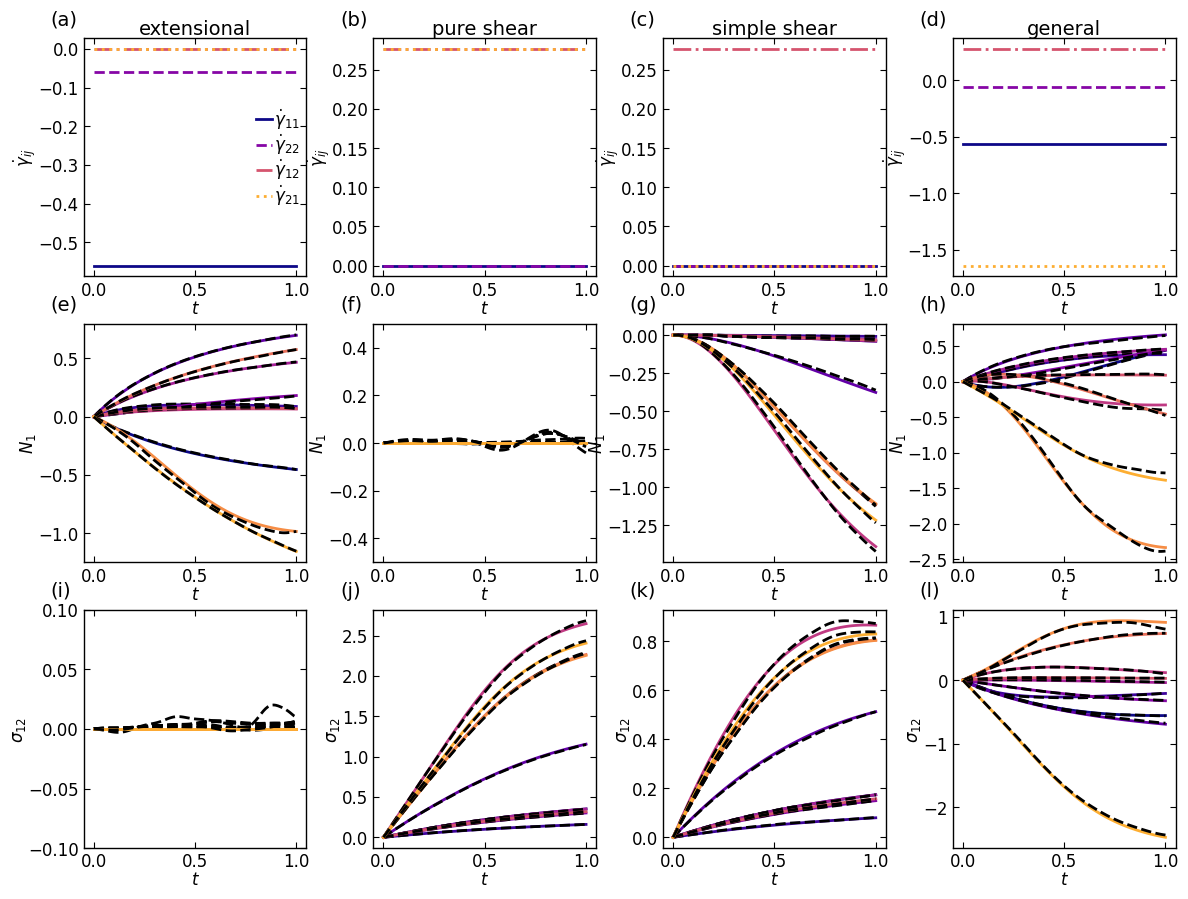

In [21]:
N_test = 100
key_test = random.PRNGKey(15)
keys_test = random.split(key_test, N_test)
P_test = 100
fig, axs = plt.subplots(3,4,figsize=(12,9))
ax = axs.flat
n = 4
t1 = np.linspace(0, tmax1, m)
omega = 0.0
u_test, x_test, s_test =  generate_extensional_data(key_test, N_test, m, P_test)
s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
ls = ['-','--','-.',':']
leg = [r'$\dot{\gamma}_{11}$',r'$\dot{\gamma}_{22}$',r'$\dot{\gamma}_{12}$',r'$\dot{\gamma}_{21}$']
for i in range(4):
    symcolor = scalarMap.to_rgba(values[3*i])
    ax[0].plot(t1,u_test[0,i*m:(i+1)*m],c=symcolor,ls=ls[i],lw=2,label=leg[i])   
i=0
for idx in range(0,N_test,10):
    index = np.arange(idx * P_test,(idx + 1) * P_test)
    symcolor = scalarMap.to_rgba(values[i])
    ax[0+n].plot(x_test[index], s_test[index, 0]-s_test[index, 1],c=symcolor,lw=2)
    ax[0+n].plot(x_test[index], s_pred[index, 0]-s_pred[index, 1],'k--',lw=2)
    ax[0+2*n].plot(x_test[index],s_test[index,2],c=symcolor,lw=2)
    ax[0+2*n].plot(x_test[index],s_pred[index,2],'k--',lw=2)
    i+=1
    
    
u_test, x_test, s_test =  generate_elongational_data(key_test, N_test, m, P_test)
s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
for i in range(4):
    symcolor = scalarMap.to_rgba(values[3*i])
    ax[1].plot(t1,u_test[0,i*m:(i+1)*m],c=symcolor,ls=ls[i],lw=2,label=leg[i])
i=0
for idx in range(0,N_test,10):
    index = np.arange(idx * P_test,(idx + 1) * P_test)
    symcolor = scalarMap.to_rgba(values[i])
    ax[1+n].plot(x_test[index], s_test[index, 0]-s_test[index, 1],c=symcolor,lw=2)
    ax[1+n].plot(x_test[index], s_pred[index, 0]-s_pred[index, 1],'k--',lw=2)
    ax[1+2*n].plot(x_test[index],s_test[index,2],c=symcolor,lw=2)
    ax[1+2*n].plot(x_test[index],s_pred[index,2],'k--',lw=2)
    i+=1
    
omega = 0.0
u_test, x_test, s_test =  generate_simpleshear_data(key_test, N_test, m, P_test)
s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
for i in range(4):
    symcolor = scalarMap.to_rgba(values[3*i])
    ax[2].plot(t1,u_test[0,i*m:(i+1)*m],c=symcolor,ls=ls[i],lw=2,label=leg[i])
i=0
for idx in range(0,N_test,10):
    index = np.arange(idx * P_test,(idx + 1) * P_test)
    symcolor = scalarMap.to_rgba(values[i])
    ax[2+n].plot(x_test[index], s_test[index, 0]-s_test[index, 1],c=symcolor,lw=2)
    ax[2+n].plot(x_test[index], s_pred[index, 0]-s_pred[index, 1],'k--',lw=2)
    ax[2+2*n].plot(x_test[index],s_test[index,2],c=symcolor,lw=2)
    ax[2+2*n].plot(x_test[index],s_pred[index,2],'k--',lw=2)
    i+=1

omega = 0.0    
u_test, x_test, s_test =  generate_general_data(key_test, N_test, m, P_test)
s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
for i in range(4):
    symcolor = scalarMap.to_rgba(values[3*i])
    ax[3].plot(t1,u_test[0,i*m:(i+1)*m],c=symcolor,ls=ls[i],lw=2,label=leg[i])
i=0
for idx in range(0,N_test,10):
    index = np.arange(idx * P_test,(idx + 1) * P_test)
    symcolor = scalarMap.to_rgba(values[i])
    ax[3+n].plot(x_test[index], s_test[index, 0]-s_test[index, 1],c=symcolor,lw=2)
    ax[3+n].plot(x_test[index], s_pred[index, 0]-s_pred[index, 1],'k--',lw=2)
    ax[3+2*n].plot(x_test[index],s_test[index,2],c=symcolor,lw=2)
    ax[3+2*n].plot(x_test[index],s_pred[index,2],'k--',lw=2)
    i+=1


label_x = [r'$t$',r'$t$',r'$t$',r'$t$']
label_y = [r'$\dot{\gamma}_{ij}$',r'$N_1$',r'$\sigma_{12}$']
title = [r'extensional',r'pure shear',r'simple shear','general']
index = [r'(a)',r'(b)',r'(c)',r'(d)',r'(e)',r'(f)',r'(g)',r'(h)',r'(i)',r'(j)',r'(k)',r'(l)']
for i in range(3):
    for j in range(4):
        ax[4*i+j].minorticks_off()
        ax[4*i+j].tick_params(axis='both',which='both',direction='in')
        ax[4*i+j].set_xlabel(label_x[j],labelpad=0)
        ax[4*i+j].set_ylabel(label_y[i],labelpad=0)
        ax[4*i+j].text(-0.15,1.08,index[4*i+j],ha='left',fontdict=font, transform=ax[4*i+j].transAxes)
for j in range(4):
    ax[j].set_title(title[j],fontdict=font)
ax[0].legend()
ax[5].set_ylim([-0.5,0.5])
ax[8].set_ylim([-0.1,0.1])
fig.subplots_adjust(left=0.04, bottom=0.05, right=0.95, top=0.95, wspace=0.3, hspace=0.2)
fig.savefig('giesekus_deeponet_fig1.png',dpi=600, transparent=False)
plt.show()

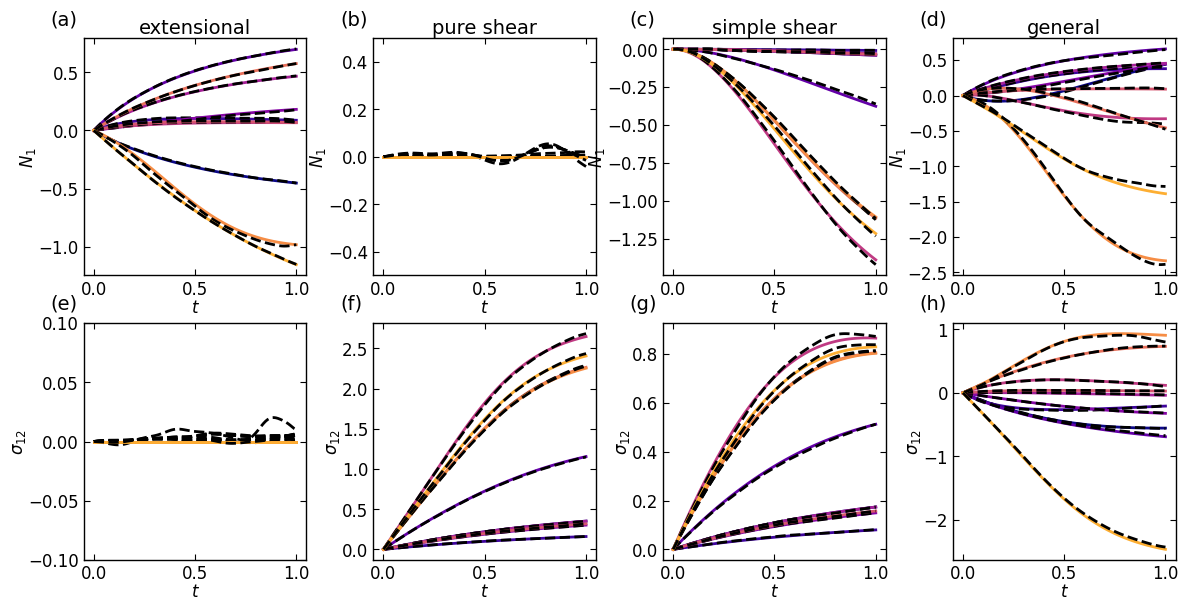

In [22]:
N_test = 100
key_test = random.PRNGKey(15)
keys_test = random.split(key_test, N_test)
P_test = 100
fig, axs = plt.subplots(2,4,figsize=(12,6))
ax = axs.flat
n = 4

omega = 0.0
u_test, x_test, s_test =  generate_extensional_data(key_test, N_test, m, P_test)
s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
i=0
for idx in range(0,N_test,10):
    index = np.arange(idx * P_test,(idx + 1) * P_test)
    symcolor = scalarMap.to_rgba(values[i])
    ax[0].plot(x_test[index], s_test[index, 0]-s_test[index, 1],c=symcolor,lw=2)
    ax[0].plot(x_test[index], s_pred[index, 0]-s_pred[index, 1],'k--',lw=2)
    ax[0+n].plot(x_test[index],s_test[index,2],c=symcolor,lw=2)
    ax[0+n].plot(x_test[index],s_pred[index,2],'k--',lw=2)
    i+=1
    
    
u_test, x_test, s_test =  generate_elongational_data(key_test, N_test, m, P_test)
s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
i=0
for idx in range(0,N_test,10):
    index = np.arange(idx * P_test,(idx + 1) * P_test)
    symcolor = scalarMap.to_rgba(values[i])
    ax[1].plot(x_test[index], s_test[index, 0]-s_test[index, 1],c=symcolor,lw=2)
    ax[1].plot(x_test[index], s_pred[index, 0]-s_pred[index, 1],'k--',lw=2)
    ax[1+n].plot(x_test[index],s_test[index,2],c=symcolor,lw=2)
    ax[1+n].plot(x_test[index],s_pred[index,2],'k--',lw=2)
    i+=1
    
omega = 0.0
u_test, x_test, s_test =  generate_simpleshear_data(key_test, N_test, m, P_test)
s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
i=0
for idx in range(0,N_test,10):
    index = np.arange(idx * P_test,(idx + 1) * P_test)
    symcolor = scalarMap.to_rgba(values[i])
    ax[2].plot(x_test[index], s_test[index, 0]-s_test[index, 1],c=symcolor,lw=2)
    ax[2].plot(x_test[index], s_pred[index, 0]-s_pred[index, 1],'k--',lw=2)
    ax[2+n].plot(x_test[index],s_test[index,2],c=symcolor,lw=2)
    ax[2+n].plot(x_test[index],s_pred[index,2],'k--',lw=2)
    i+=1

omega = 0.0    
u_test, x_test, s_test =  generate_general_data(key_test, N_test, m, P_test)
s_pred = model.predict(tf.convert_to_tensor(u_test,dtype=DTYPE),tf.convert_to_tensor(x_test,dtype=DTYPE))
i=0
for idx in range(0,N_test,10):
    index = np.arange(idx * P_test,(idx + 1) * P_test)
    symcolor = scalarMap.to_rgba(values[i])
    ax[3].plot(x_test[index], s_test[index, 0]-s_test[index, 1],c=symcolor,lw=2)
    ax[3].plot(x_test[index], s_pred[index, 0]-s_pred[index, 1],'k--',lw=2)
    ax[3+n].plot(x_test[index],s_test[index,2],c=symcolor,lw=2)
    ax[3+n].plot(x_test[index],s_pred[index,2],'k--',lw=2)
    i+=1


label_x = [r'$t$',r'$t$',r'$t$',r'$t$']
label_y = [r'$N_1$',r'$\sigma_{12}$']
title = [r'extensional',r'pure shear',r'simple shear','general']
index = [r'(a)',r'(b)',r'(c)',r'(d)',r'(e)',r'(f)',r'(g)',r'(h)',r'(i)',r'(j)',r'(k)',r'(l)']
for i in range(2):
    for j in range(4):
        ax[4*i+j].minorticks_off()
        ax[4*i+j].tick_params(axis='both',which='both',direction='in')
        ax[4*i+j].set_xlabel(label_x[j],labelpad=0)
        ax[4*i+j].set_ylabel(label_y[i],labelpad=0)
        ax[4*i+j].text(-0.15,1.08,index[4*i+j],ha='left',fontdict=font, transform=ax[4*i+j].transAxes)
for j in range(4):
    ax[j].set_title(title[j],fontdict=font)
ax[1].set_ylim([-0.5,0.5])
ax[4].set_ylim([-0.1,0.1])
fig.subplots_adjust(left=0.04, bottom=0.08, right=0.95, top=0.95, wspace=0.3, hspace=0.2)
fig.savefig('giesekus_deeponet_fig2.png',dpi=600, transparent=False)
plt.show()